# EDA — Pollen & Météo
**Projet Antihistaminiques France — Jedha 2026**

## Objectif
Analyser les concentrations polliniques et les données météo pour identifier les features ML pertinentes.

## Sources
- `J0_silver_cams_pollen_2023_2026.csv` — Copernicus CAMS, grille 0.1°, 6 taxons
- `J0_silver_meteo_2023_2026.csv` — Météo-France, 13 régions, 2023-2026

## Plan
1. Chargement & agrégation
2. Evolution temporelle des taxons
3. Saisonnalité par mois
4. Carte par région
5. Random Forest — prédiction graminées
6. Feature importance
7. Synthèse

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Chargement
df_pollen = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_cams_pollen_2023_2026.csv', low_memory=False)
df_meteo  = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_meteo_2023_2026.csv')

df_pollen['date'] = pd.to_datetime(df_pollen['date'])
df_meteo['time']  = pd.to_datetime(df_meteo['time'])

# Agrégation pollen par date (moyenne nationale)
pollen_daily = df_pollen.groupby('date').agg(
    graminees=('graminees_conc', 'mean'),
    bouleau=('bouleau_conc',     'mean'),
    aulne=('aulne_conc',         'mean'),
    ambroisie=('ambroisie_conc', 'mean'),
    armoise=('armoise_conc',     'mean'),
    olivier=('olivier_conc',     'mean')
).reset_index()
pollen_daily['mois']      = pollen_daily['date'].dt.month
pollen_daily['annee']     = pollen_daily['date'].dt.year
pollen_daily['jour_annee']= pollen_daily['date'].dt.dayofyear
pollen_daily['saison_allergies'] = pollen_daily['mois'].apply(lambda m: 1 if m in [4,5,6,7] else 0)

mois_noms = {1:'Jan',2:'Fev',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
             7:'Jul',8:'Aou',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print(f'Pollen : {pollen_daily.shape} | Periode : {pollen_daily.date.min().date()} -> {pollen_daily.date.max().date()}')
print(f'Meteo  : {df_meteo.shape} | Regions : {df_meteo.region.nunique()}')

Pollen : (1021, 11) | Periode : 2023-05-27 -> 2026-06-01
Meteo  : (16211, 8) | Regions : 13


## 1. Evolution temporelle des concentrations polliniques
> **Observation** : 3 pics nets de graminées en mai-juin (2023, 2024, 2025). Le bouleau pic intensément en avril (pic court, 2-3 semaines). L'aulne est le premier pollen de l'année (janvier-mars).

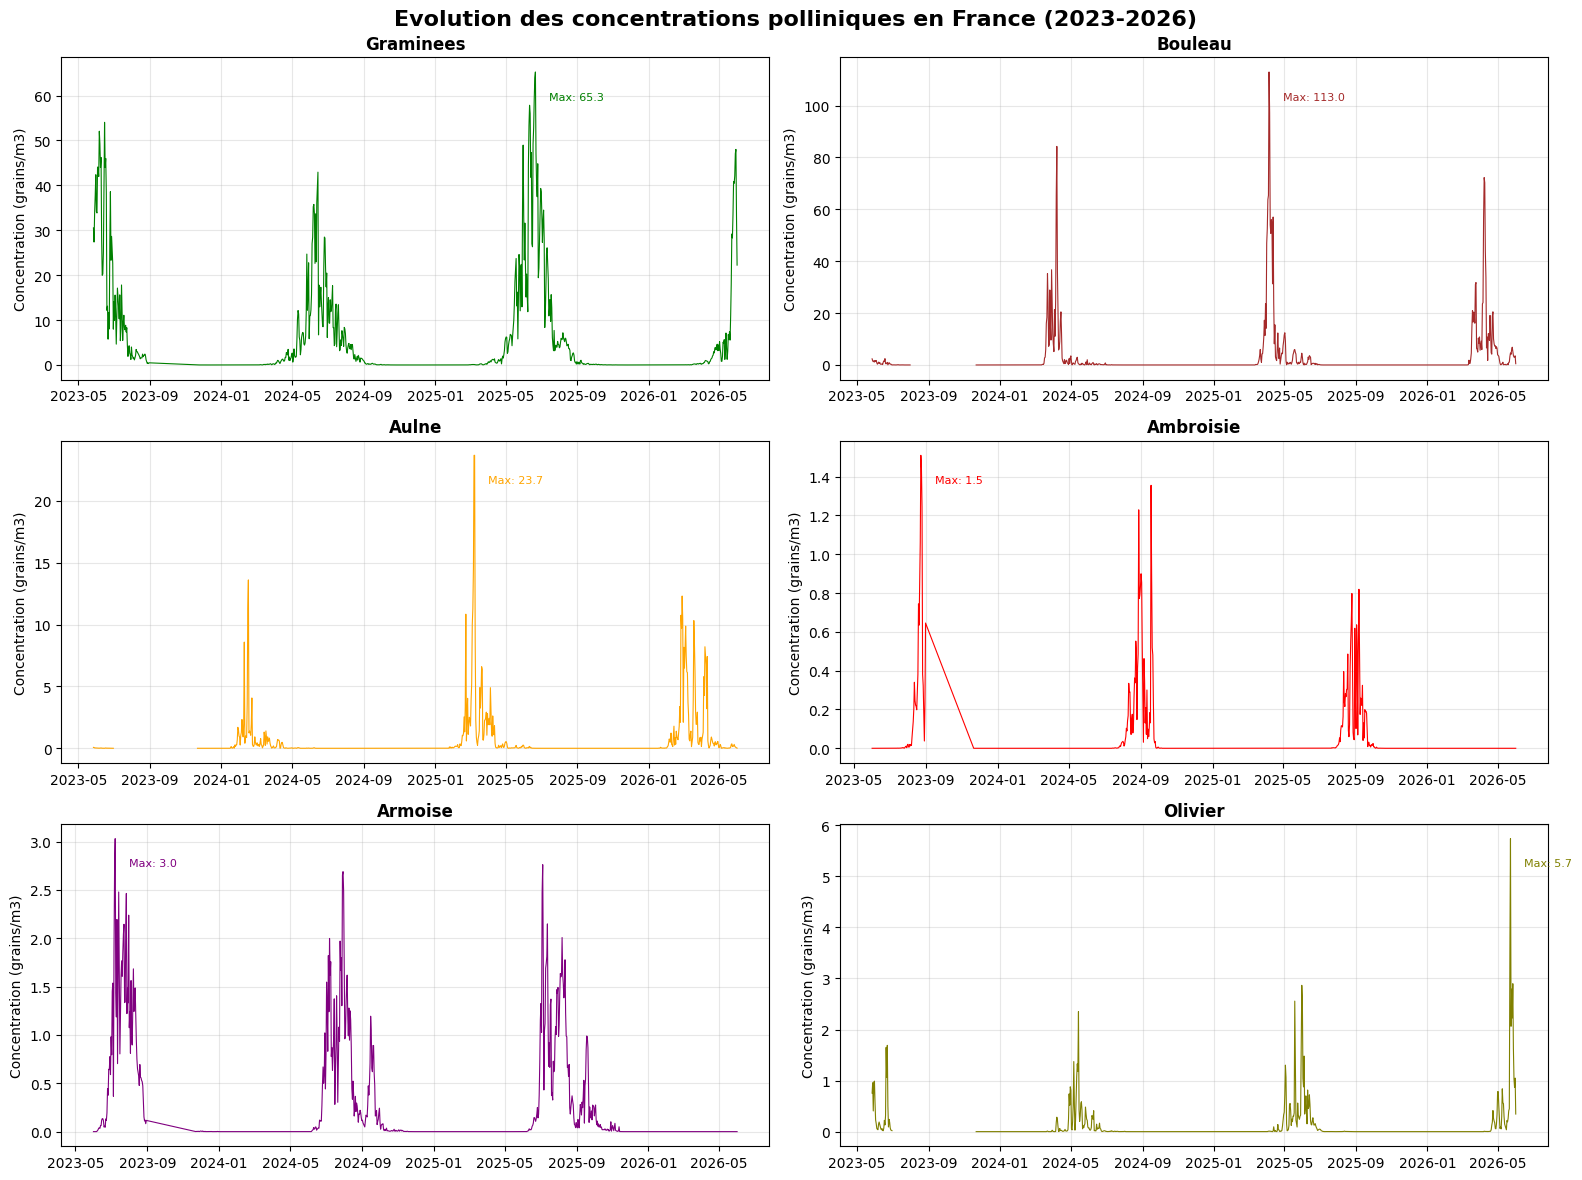

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Evolution des concentrations polliniques en France (2023-2026)',
             fontsize=16, fontweight='bold')

taxons = {
    'graminees': ('Graminees', 'green',  axes[0,0]),
    'bouleau':   ('Bouleau',   'brown',  axes[0,1]),
    'aulne':     ('Aulne',     'orange', axes[1,0]),
    'ambroisie': ('Ambroisie', 'red',    axes[1,1]),
    'armoise':   ('Armoise',   'purple', axes[2,0]),
    'olivier':   ('Olivier',   'olive',  axes[2,1]),
}

for col, (label, color, ax) in taxons.items():
    ax.plot(pollen_daily['date'], pollen_daily[col], color=color, linewidth=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Concentration (grains/m3)')
    ax.grid(True, alpha=0.3)
    max_val  = pollen_daily[col].max()
    max_date = pollen_daily.loc[pollen_daily[col].idxmax(), 'date']
    ax.annotate(f'Max: {max_val:.1f}', xy=(max_date, max_val),
                xytext=(10, -20), textcoords='offset points', fontsize=8, color=color)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Saisonnalite par mois
> **Observation** : Juin est le mois critique — 30 grains/m3 en moyenne pour les graminees. Avril domine pour le bouleau. La fenetre **avril-juillet** concentre 90% de l'exposition pollinique totale.

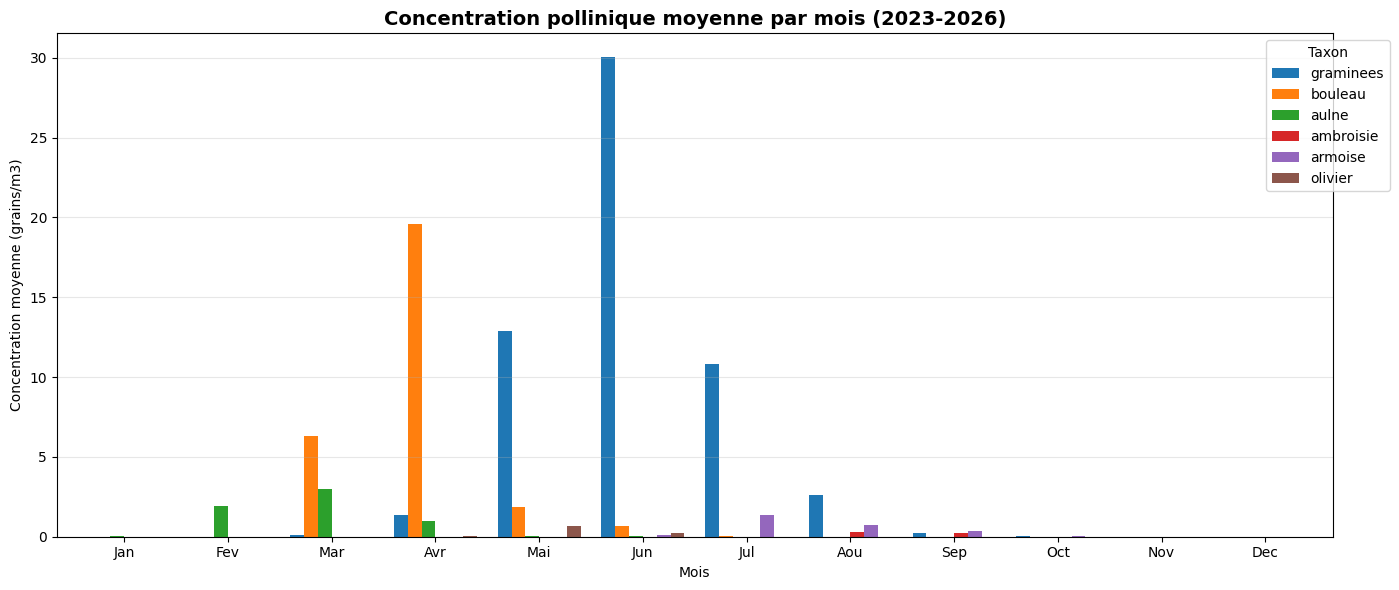

In [10]:
saison = pollen_daily.groupby('mois')[
    ['graminees','bouleau','aulne','ambroisie','armoise','olivier']
].mean()

fig, ax = plt.subplots(figsize=(14, 6))
saison.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Concentration pollinique moyenne par mois (2023-2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Concentration moyenne (grains/m3)')
ax.set_xticklabels(['Jan','Fev','Mar','Avr','Mai','Jun',
                    'Jul','Aou','Sep','Oct','Nov','Dec'], rotation=0)
ax.legend(title='Taxon', bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Carte des graminees par region AASQA (juin)
> **Observation** : Le Centre-Nord (Auvergne-Rhone-Alpes, Grand Est) est la zone la plus exposee en juin. Cohérent avec les données Open Medic — ce sont aussi les régions avec le plus de remboursements R06A.

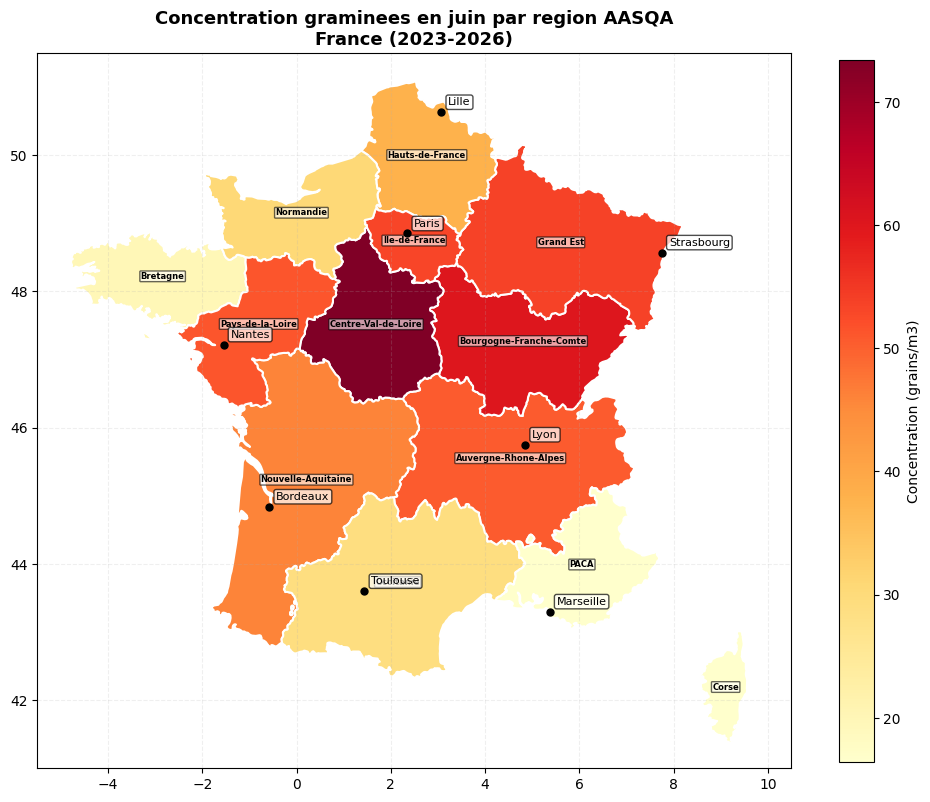

In [11]:
mapping_dept_region = {
    'Paris':'Ile-de-France','Hauts-de-Seine':'Ile-de-France',
    'Seine-Saint-Denis':'Ile-de-France',"Val-d'Oise":'Ile-de-France',
    'Yvelines':'Ile-de-France','Essonne':'Ile-de-France',
    'Seien-et-Marne':'Ile-de-France','Val-de-Marne':'Ile-de-France',
    'Nord':'Hauts-de-France','Pas-de-Calais':'Hauts-de-France',
    'Somme':'Hauts-de-France','Aisne':'Hauts-de-France','Oise':'Hauts-de-France',
    'Ardennes':'Grand Est','Meuse':'Grand Est','Meurthe-et-Moselle':'Grand Est',
    'Moselle':'Grand Est','Bas-Rhin':'Grand Est','Haute-Rhin':'Grand Est',
    'Vosges':'Grand Est','Marne':'Grand Est','Haute-Marne':'Grand Est','Aube':'Grand Est',
    'Seine-Maritime':'Normandie','Eure':'Normandie','Calvados':'Normandie',
    'Manche':'Normandie','Orne':'Normandie',
    'Finistere':'Bretagne',"Cotes-d'Armor":'Bretagne',
    'Morbihan':'Bretagne','Ille-et-Vilaine':'Bretagne',
    'Loire-Atlantique':'Pays-de-la-Loire','Vendee':'Pays-de-la-Loire',
    'Maine-et-Loire':'Pays-de-la-Loire','Sarthe':'Pays-de-la-Loire','Mayenne':'Pays-de-la-Loire',
    'Loiret':'Centre-Val-de-Loire','Loir-et-Cher':'Centre-Val-de-Loire',
    'Indre-et-Loire':'Centre-Val-de-Loire','Indre':'Centre-Val-de-Loire',
    'Cher':'Centre-Val-de-Loire','Eure-et-Loir':'Centre-Val-de-Loire',
    "Cote-d'Or":'Bourgogne-Franche-Comte','Nievre':'Bourgogne-Franche-Comte',
    'Saone-et-Loire':'Bourgogne-Franche-Comte','Yonne':'Bourgogne-Franche-Comte',
    'Doubs':'Bourgogne-Franche-Comte','Jura':'Bourgogne-Franche-Comte',
    'Haute-Saone':'Bourgogne-Franche-Comte','Territoire de Belfort':'Bourgogne-Franche-Comte',
    'Gironde':'Nouvelle-Aquitaine','Dordogne':'Nouvelle-Aquitaine',
    'Lot-et-Garonne':'Nouvelle-Aquitaine','Landes':'Nouvelle-Aquitaine',
    'Pyrenees-Atlantiques':'Nouvelle-Aquitaine','Charente':'Nouvelle-Aquitaine',
    'Charente-Maritime':'Nouvelle-Aquitaine','Deux-Sevres':'Nouvelle-Aquitaine',
    'Vienne':'Nouvelle-Aquitaine','Haute-Vienne':'Nouvelle-Aquitaine',
    'Correze':'Nouvelle-Aquitaine','Creuse':'Nouvelle-Aquitaine',
    'Haute-Garonne':'Occitanie','Hautes-Pyrenees':'Occitanie',
    'Ariege':'Occitanie','Pyrenees-Orientales':'Occitanie','Aude':'Occitanie',
    'Herault':'Occitanie','Gard':'Occitanie','Lozere':'Occitanie',
    'Aveyron':'Occitanie','Lot':'Occitanie','Tarn':'Occitanie',
    'Tarn-et-Garonne':'Occitanie','Gers':'Occitanie',
    'Rhone':'Auvergne-Rhone-Alpes','Ain':'Auvergne-Rhone-Alpes',
    'Loire':'Auvergne-Rhone-Alpes','Isere':'Auvergne-Rhone-Alpes',
    'Drome':'Auvergne-Rhone-Alpes','Ardeche':'Auvergne-Rhone-Alpes',
    'Savoie':'Auvergne-Rhone-Alpes','Haute-Savoie':'Auvergne-Rhone-Alpes',
    'Puy-de-Dome':'Auvergne-Rhone-Alpes','Allier':'Auvergne-Rhone-Alpes',
    'Haute-Loire':'Auvergne-Rhone-Alpes','Cantal':'Auvergne-Rhone-Alpes',
    'Bouches-du-Rhone':'PACA','Var':'PACA','Vaucluse':'PACA',
    'Alpes-Maritimes':'PACA','Alpes-de-Haute-Provence':'PACA','Hautes-Alpes':'PACA',
    'Haute-Corse':'Corse','Corse-du-Sud':'Corse',
}

regions = gpd.read_file('https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip')
regions_fr = regions[regions['admin'] == 'France'].copy()
regions_fr['name_clean'] = regions_fr['name'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii')
regions_fr['region'] = regions_fr['name_clean'].map(
    {k.encode('ascii','ignore').decode('ascii'):v for k,v in mapping_dept_region.items()}
)
regions_fr = regions_fr[regions_fr['region'].notna()]
regions_13  = regions_fr.dissolve(by='region').reset_index()

juin = df_pollen[df_pollen['date'].dt.month == 6].copy()
gdf_juin = gpd.GeoDataFrame(juin,
    geometry=gpd.points_from_xy(juin['longitude'], juin['latitude']), crs='EPSG:4326')
joined = gpd.sjoin(gdf_juin, regions_13[['region','geometry']], how='left', predicate='within')
conc_region = joined.groupby('region')['graminees_conc'].mean().reset_index()
conc_region.columns = ['region','graminees_moy']
regions_13 = regions_13.merge(conc_region, on='region', how='left')

villes = {
    'Paris':(48.85,2.35),'Lyon':(45.75,4.85),'Marseille':(43.30,5.37),
    'Toulouse':(43.60,1.44),'Bordeaux':(44.84,-0.58),'Nantes':(47.22,-1.55),
    'Strasbourg':(48.57,7.75),'Lille':(50.63,3.07),
}

fig, ax = plt.subplots(figsize=(10, 12))
regions_13.plot(column='graminees_moy', cmap='YlOrRd', linewidth=1.5,
                edgecolor='white', ax=ax, legend=True,
                missing_kwds={'color':'lightgray'},
                legend_kwds={'label':'Concentration (grains/m3)', 'shrink':0.6})

for _, row in regions_13.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(row['region'], xy=(centroid.x, centroid.y),
                ha='center', fontsize=6, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6))

for ville, (lat, lon) in villes.items():
    ax.plot(lon, lat, 'o', color='black', markersize=5, zorder=10)
    ax.annotate(ville, xy=(lon, lat), xytext=(5,5), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('Concentration graminees en juin par region AASQA\nFrance (2023-2026)',
             fontsize=13, fontweight='bold')
ax.set_xlim(-5.5, 10.5)
ax.set_ylim(41.0, 51.5)
ax.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/carte_graminees_regions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Random Forest — Prediction des graminees
> **Objectif** : Predire la concentration en graminees a partir des variables meteo et temporelles.

> **Features** : temperature max/min/moy, precipitations, vent, mois, jour de l'annee, flag saison allergies

> **Resultats obtenus** : R2 global 0.84 — le modele explique 84% de la variance. La position temporelle (jour_annee, saison_allergies) domine largement.

In [12]:
# Preprocessing
meteo_daily = df_meteo.groupby('time').agg(
    temp_moy=('temperature_2m_mean', 'mean'),
    temp_max=('temperature_2m_max',  'mean'),
    temp_min=('temperature_2m_min',  'mean'),
    precip=('precipitation_sum',     'mean'),
    wind=('wind_speed_10m_max',      'mean')
).reset_index().rename(columns={'time':'date'})

merged = pollen_daily.merge(meteo_daily, on='date', how='inner')
merged['mois']             = merged['date'].dt.month
merged['annee']            = merged['date'].dt.year
merged['jour_annee']       = merged['date'].dt.dayofyear
merged['saison_allergies'] = merged['mois'].apply(lambda m: 1 if m in [4,5,6,7] else 0)

features = ['temp_moy','temp_max','temp_min','precip','wind','mois','jour_annee','saison_allergies']

def run_rf(df):
    X = df[features]
    y = df['graminees']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    return y_test, y_pred, r2_score(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred)), rf

resultats = {}
y_test, y_pred, r2, rmse, rf = run_rf(merged)
resultats['toutes'] = {'df':merged,'y_test':y_test,'y_pred':y_pred,'r2':r2,'rmse':rmse,'label':'Toutes annees 2023-2026','color':'purple'}

colors = {2023:'steelblue',2024:'coral',2025:'mediumseagreen',2026:'mediumpurple'}
for annee in sorted(merged['annee'].unique()):
    df_an = merged[merged['annee']==annee]
    if len(df_an) < 50:
        continue
    y_t,y_p,r2_,rmse_,rf_ = run_rf(df_an)
    resultats[annee] = {'df':df_an,'y_test':y_t,'y_pred':y_p,'r2':r2_,'rmse':rmse_,'label':f'Annee {annee}','color':colors.get(annee,'purple')}

print('Resultats Random Forest :')
for k,v in resultats.items():
    print(f"  {v['label']:<25} R2 = {v['r2']:.3f} | RMSE = {v['rmse']:.3f} | n = {len(v['df'])}")

Resultats Random Forest :
  Toutes annees 2023-2026   R2 = 0.840 | RMSE = 4.589 | n = 1020
  Annee 2023                R2 = 0.875 | RMSE = 5.498 | n = 138
  Annee 2024                R2 = 0.790 | RMSE = 2.993 | n = 366
  Annee 2025                R2 = 0.891 | RMSE = 2.301 | n = 365
  Annee 2026                R2 = 0.942 | RMSE = 2.330 | n = 151


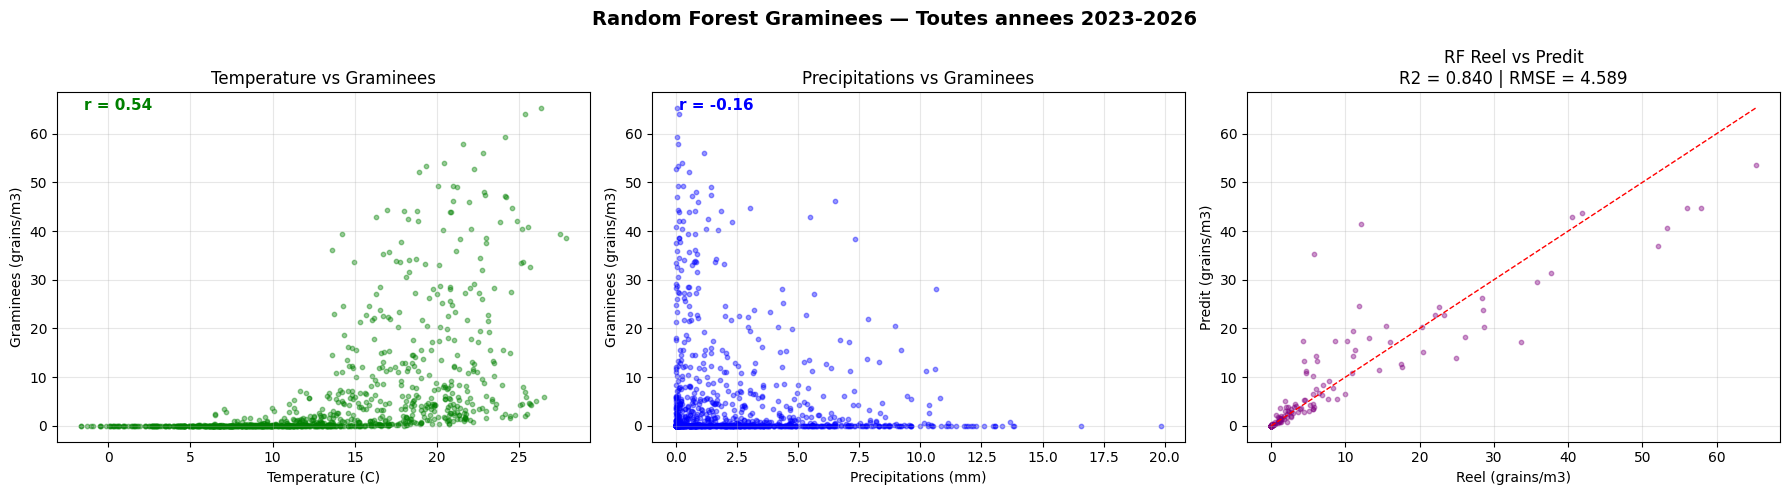

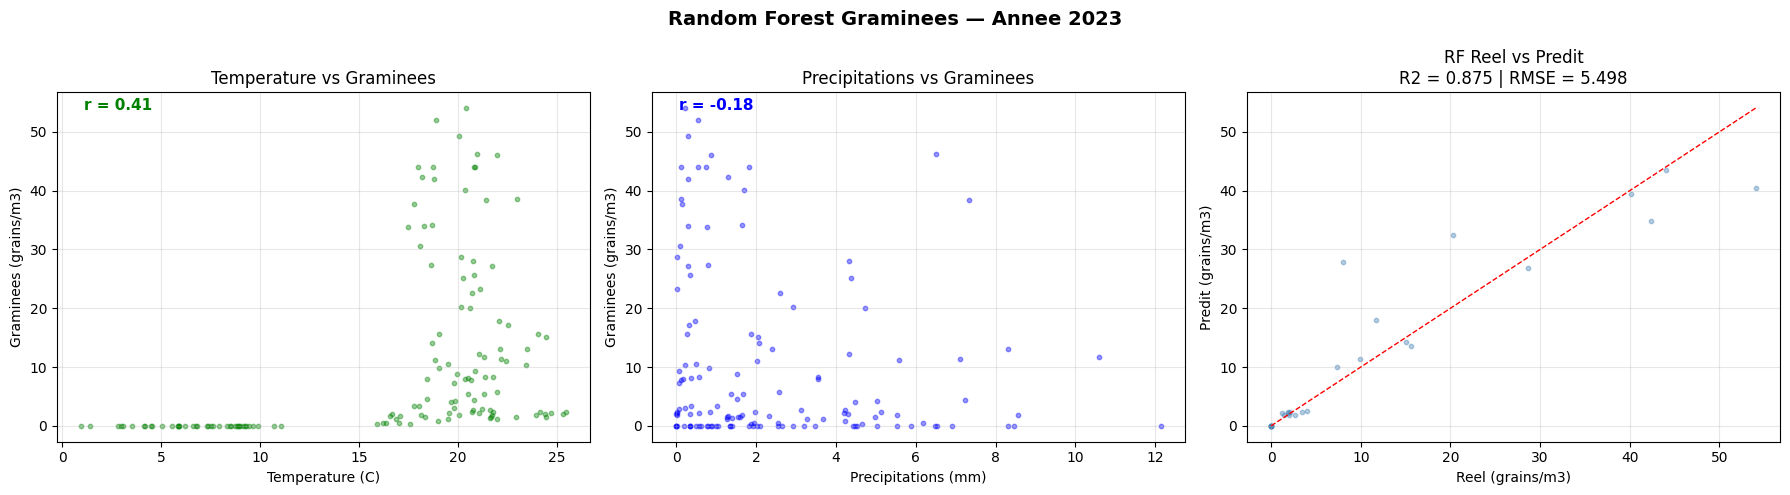

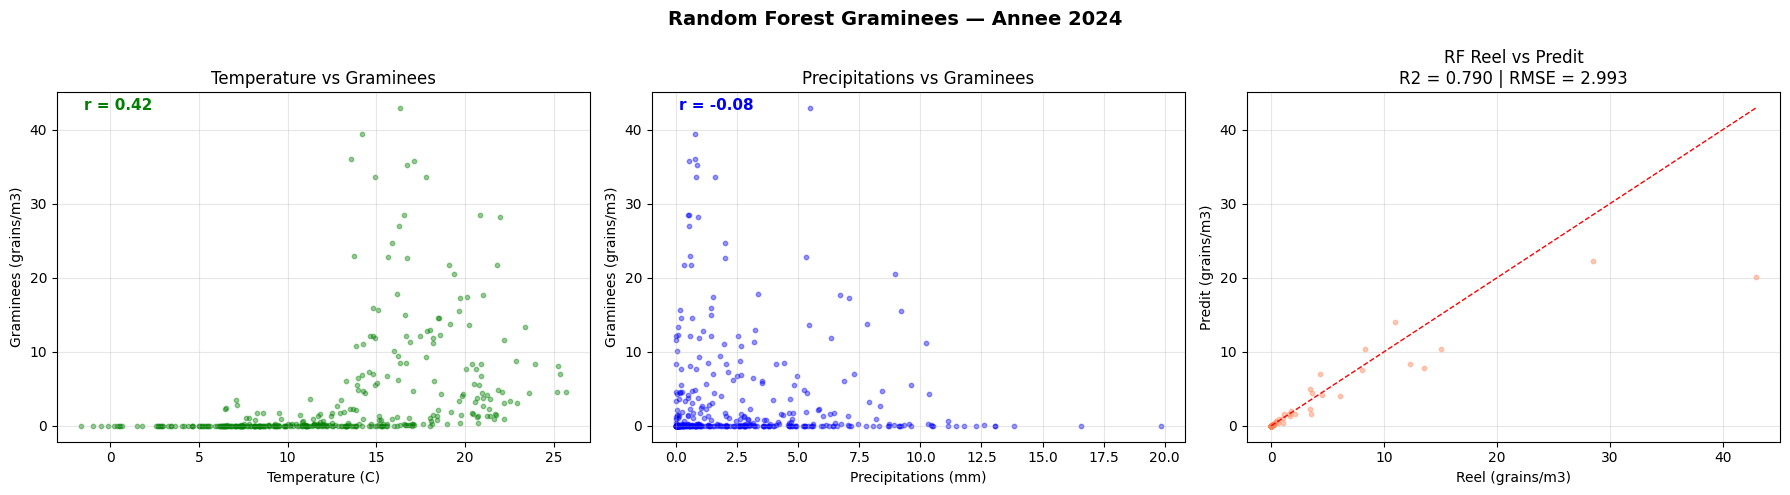

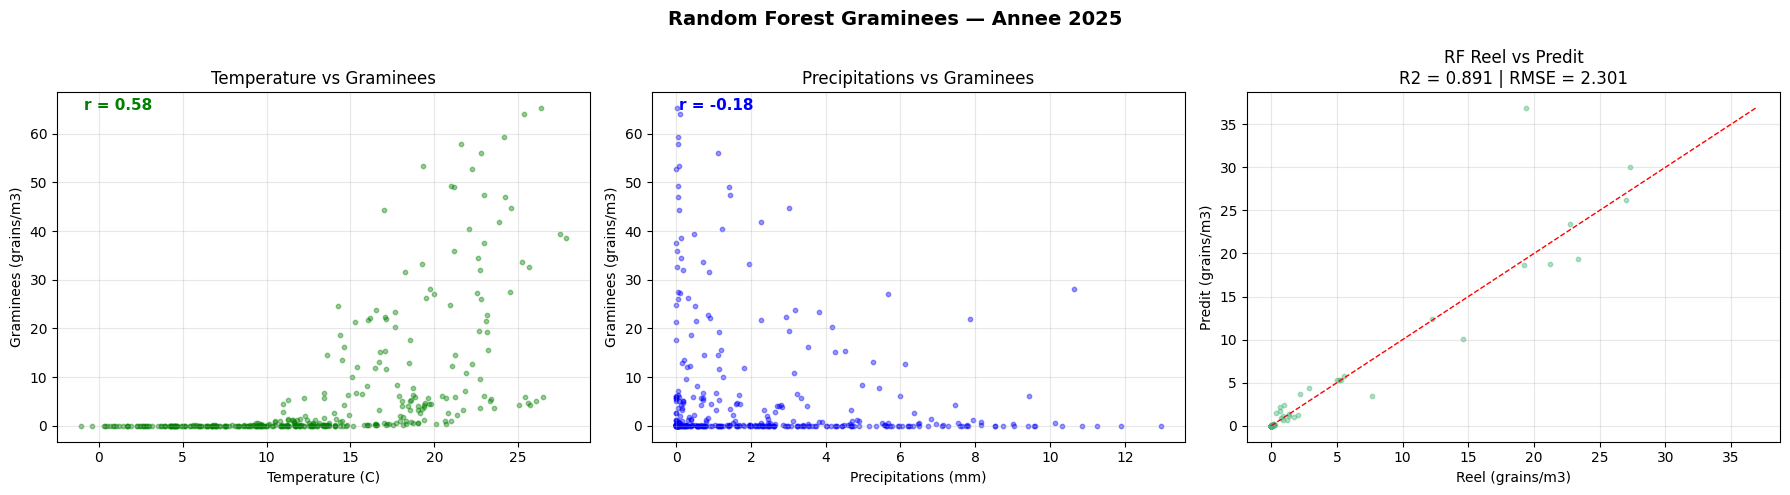

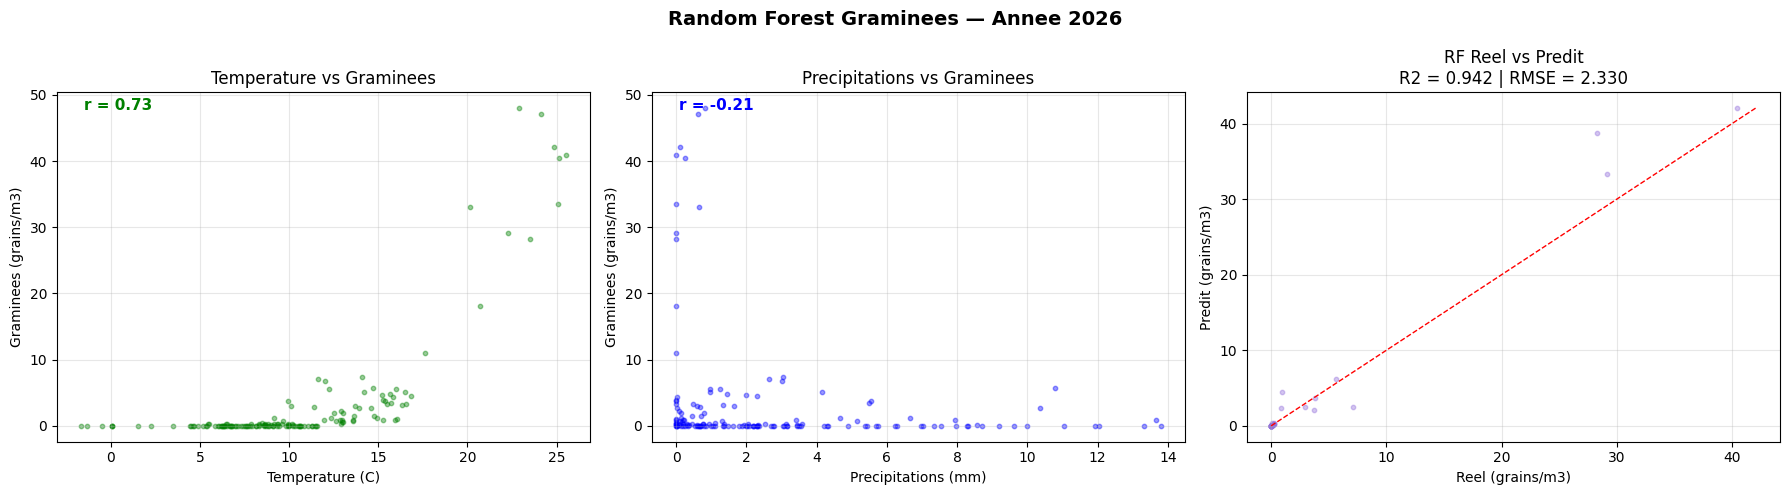

In [13]:
# Graphiques RF par periode
def plot_bloc(res):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Random Forest Graminees — {res['label']}", fontsize=14, fontweight='bold')

    # Temp vs Graminees
    c_t = res['df']['temp_moy'].corr(res['df']['graminees'])
    axes[0].scatter(res['df']['temp_moy'], res['df']['graminees'], alpha=0.4, color='green', s=10)
    axes[0].set_xlabel('Temperature (C)')
    axes[0].set_ylabel('Graminees (grains/m3)')
    axes[0].set_title('Temperature vs Graminees')
    axes[0].grid(True, alpha=0.3)
    axes[0].annotate(f'r = {c_t:.2f}', xy=(0.05,0.95), xycoords='axes fraction', fontsize=11, color='green', fontweight='bold')

    # Precip vs Graminees
    c_p = res['df']['precip'].corr(res['df']['graminees'])
    axes[1].scatter(res['df']['precip'], res['df']['graminees'], alpha=0.4, color='blue', s=10)
    axes[1].set_xlabel('Precipitations (mm)')
    axes[1].set_ylabel('Graminees (grains/m3)')
    axes[1].set_title('Precipitations vs Graminees')
    axes[1].grid(True, alpha=0.3)
    axes[1].annotate(f'r = {c_p:.2f}', xy=(0.05,0.95), xycoords='axes fraction', fontsize=11, color='blue', fontweight='bold')

    # Reel vs Predit
    max_val = max(float(res['y_test'].max()), float(res['y_pred'].max()))
    axes[2].scatter(res['y_test'], res['y_pred'], alpha=0.4, color=res['color'], s=10)
    axes[2].plot([0,max_val],[0,max_val],'r--',linewidth=1)
    axes[2].set_xlabel('Reel (grains/m3)')
    axes[2].set_ylabel('Predit (grains/m3)')
    axes[2].set_title(f"RF Reel vs Predit\nR2 = {res['r2']:.3f} | RMSE = {res['rmse']:.3f}")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = res['label'].replace(' ','_').replace('-','_')
    plt.savefig(f"/Users/nellyta/Jedha/notebooks/rf_{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()

for key in resultats:
    plot_bloc(resultats[key])

## 5. Feature Importance
> **Resultat cle** : `jour_annee` (0.43) et `saison_allergies` (0.31) representent 74% de l'importance totale. La position temporelle prime sur la meteo — la saisonnalite est le principal determinant des concentrations polliniques.

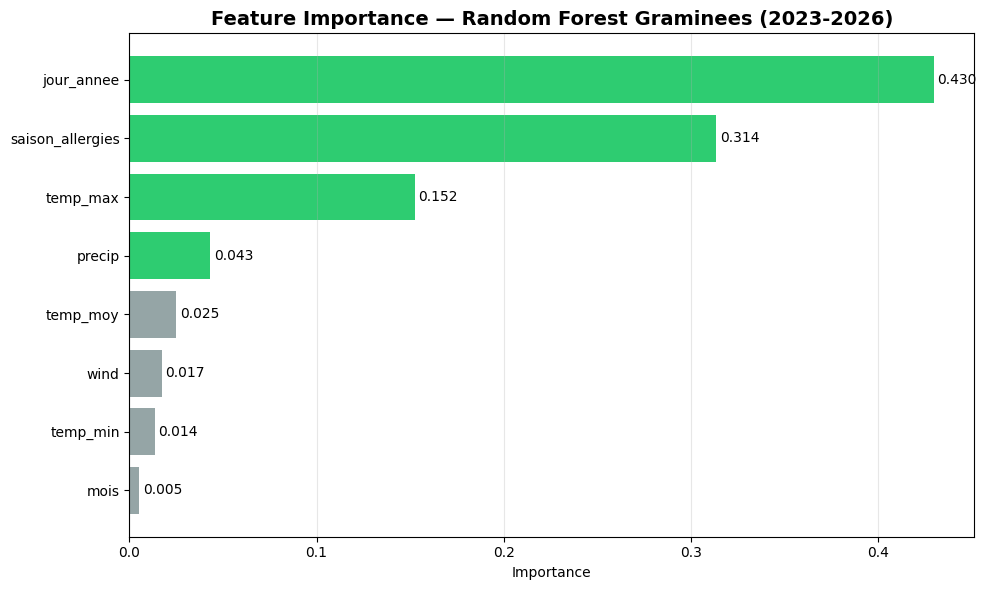

In [14]:
rf_all = RandomForestRegressor(n_estimators=100, random_state=42)
rf_all.fit(merged[features], merged['graminees'])

importance = pd.DataFrame({'feature':features,'importance':rf_all.feature_importances_}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance['feature'], importance['importance'],
               color=['#2ecc71' if i > importance['importance'].median() else '#95a5a6' for i in importance['importance']])
ax.set_title('Feature Importance — Random Forest Graminees (2023-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, importance['importance']):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Synthese

### Resultats cles

| Indicateur | Valeur |
|-----------|--------|
| Periode analysee | 2023-2026 |
| Jours de donnees | 1 021 |
| Mois critique graminees | Juin (30 grains/m3 moy) |
| Region la plus exposee | Centre-Nord (Auvergne-RA) |
| R2 modele global | 0.84 |
| Feature la plus importante | jour_annee (0.43) |
| Correlation temp/graminees | 0.54 |

### Features ML retenues pour J4
- `jour_annee` — position dans l'annee (feature #1)
- `saison_allergies` — flag avril-juillet
- `temp_max` — temperature maximale journaliere
- `precip` — precipitations
- `mois` — saisonnalite

### Ce qui sera ajoute en J4
- `gram_lag_7j` — concentration pollen J-7
- `gram_rolling_7j` — moyenne glissante 7 jours
- `cumul_thermique` — somme des temperatures depuis janvier
